# Conjunto de datos Penguin

El conjunto de datos Penguin es un recurso ampliamente utilizado en ciencia de datos para el análisis exploratorio y la práctica de técnicas estadísticas y de machine learning. Este dataset contiene información sobre diferentes especies de pingüinos recolectada en varias islas de la Antártida.

Incluye variables como especie, isla, longitud y profundidad del pico, masa corporal, sexo, y año de recolección. Es ideal para ejercicios de clasificación, regresión y visualización de datos, y permite explorar relaciones entre características biológicas y ambientales de los pingüinos.

In [4]:
# cargar el conjunto de datos Pingüin
import seaborn as sns # biblioteca para visualización de datos
import pandas as pd # biblioteca para manipulación y análisis de datos
import matplotlib.pyplot as plt # biblioteca para creación de gráficos
import numpy as np # biblioteca para operaciones numéricas
from sklearn.model_selection import train_test_split # función para dividir el conjunto de datos
from sklearn.linear_model import LinearRegression # modelo de regresión lineal
from sklearn.metrics import mean_squared_error, r2_score # métricas de evaluación

# Cargar el conjunto de datos de pingüinos
data = sns.load_dataset('penguins')
#data = data.dropna()  # Eliminar filas con valores nulos
print(data.head())


  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


In [5]:
data.shape

(344, 7)

## Muestra aleatoria de datos
En lugar de mostrar los primeros registros del conjunto de datos, a continuación se muestra una muestra aleatoria de filas. Esto permite observar la diversidad de los datos y verificar que la carga se realizó correctamente.

In [6]:
# Mostrar una muestra aleatoria de 6 filas del conjunto de datos
data.sample(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
315,Gentoo,Biscoe,50.8,15.7,226.0,5200.0,Male
142,Adelie,Dream,32.1,15.5,188.0,3050.0,Female
92,Adelie,Dream,34.0,17.1,185.0,3400.0,Female
166,Chinstrap,Dream,45.9,17.1,190.0,3575.0,Female
243,Gentoo,Biscoe,46.3,15.8,215.0,5050.0,Male
278,Gentoo,Biscoe,43.2,14.5,208.0,4450.0,Female
240,Gentoo,Biscoe,50.2,14.3,218.0,5700.0,Male
172,Chinstrap,Dream,42.4,17.3,181.0,3600.0,Female
252,Gentoo,Biscoe,45.1,14.5,207.0,5050.0,Female
281,Gentoo,Biscoe,46.2,14.9,221.0,5300.0,Male


## Descripción de los campos del conjunto de datos Penguin
A continuación se describen los principales campos presentes en el dataset:

- **species**: Especie del pingüino (Adelie, Chinstrap, Gentoo).
- **island**: Isla donde se recolectó la muestra (Biscoe, Dream, Torgersen).
- **bill_length_mm**: Longitud del pico en milímetros.
- **bill_depth_mm**: Profundidad del pico en milímetros.
- **flipper_length_mm**: Longitud de la aleta en milímetros.
- **body_mass_g**: Masa corporal en gramos.
- **sex**: Sexo del pingüino (male, female).

Estos campos permiten realizar análisis comparativos y explorar relaciones entre las características físicas y el entorno de los pingüinos.

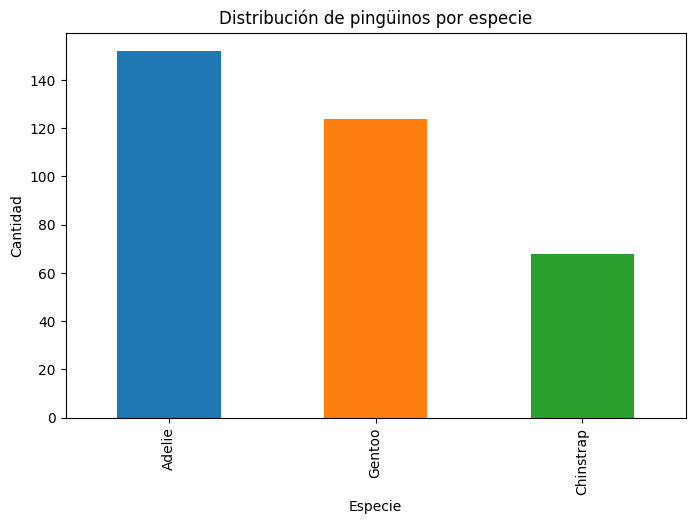

In [7]:
# Gráfico de barras: distribución de pingüinos por especie
plt.figure(figsize=(8,5))
data['species'].value_counts().plot(kind='bar', color=['#1f77b4','#ff7f0e','#2ca02c'])
plt.title('Distribución de pingüinos por especie')
plt.xlabel('Especie')
plt.ylabel('Cantidad')
plt.show()

## Observaciones sobre la frecuencia de especies
- El pingüino Adelie es el más frecuente en el conjunto de datos.
- La cantidad de pingüinos Adelie es más del doble que la clase minoritaria, que corresponde al pingüino Chinstrap (representado en color verde en el gráfico).
- Existe un cierto desbalance entre las clases, lo que podría impactar en el desempeño de modelos de clasificación o predicción posteriores.

Estas observaciones son importantes para considerar estrategias de balanceo de clases si se desarrollan modelos de machine learning con este dataset.

island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0


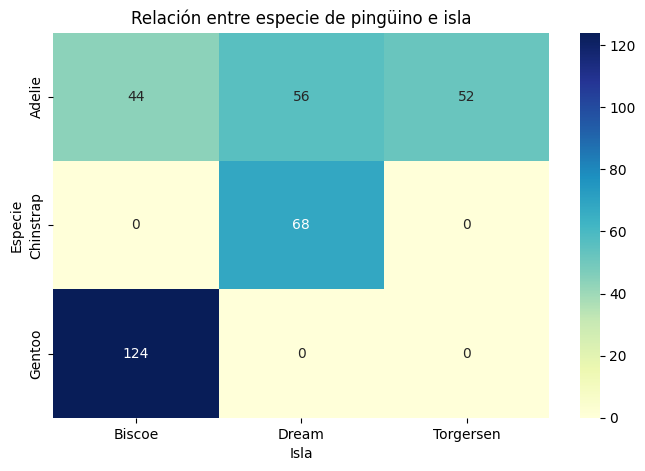

In [8]:
# Tabla de contingencia: relación entre especie de pingüino e isla
contingencia = pd.crosstab(data['species'], data['island'])
print(contingencia)

# Gráfico de calor para la tabla de contingencia
plt.figure(figsize=(8,5))
sns.heatmap(contingencia, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Relación entre especie de pingüino e isla')
plt.xlabel('Isla')
plt.ylabel('Especie')
plt.show()

## Observaciones sobre la relación especie-isla
- El pingüino Gentoo solo se encuentra en la isla Biscoe.
- El pingüino Chinstrap únicamente habita en Dream Island.
- El pingüino Adelie está presente en las tres islas (Biscoe, Dream y Torgersen) y su distribución es bastante uniforme entre ellas.

Estas observaciones permiten identificar patrones de hábitat y distribución geográfica entre las especies de pingüinos del conjunto de datos.

Cantidad de datos faltantes por columna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


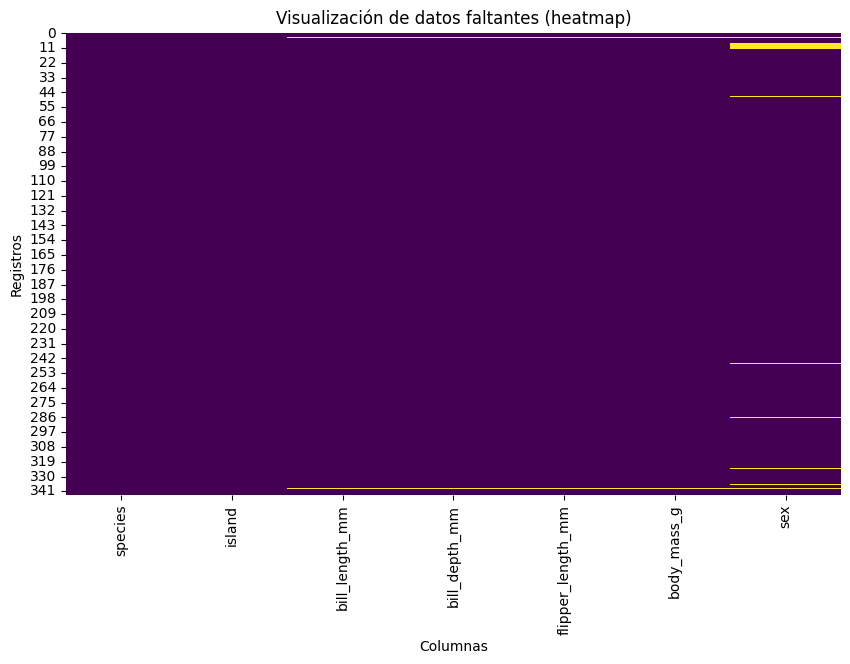

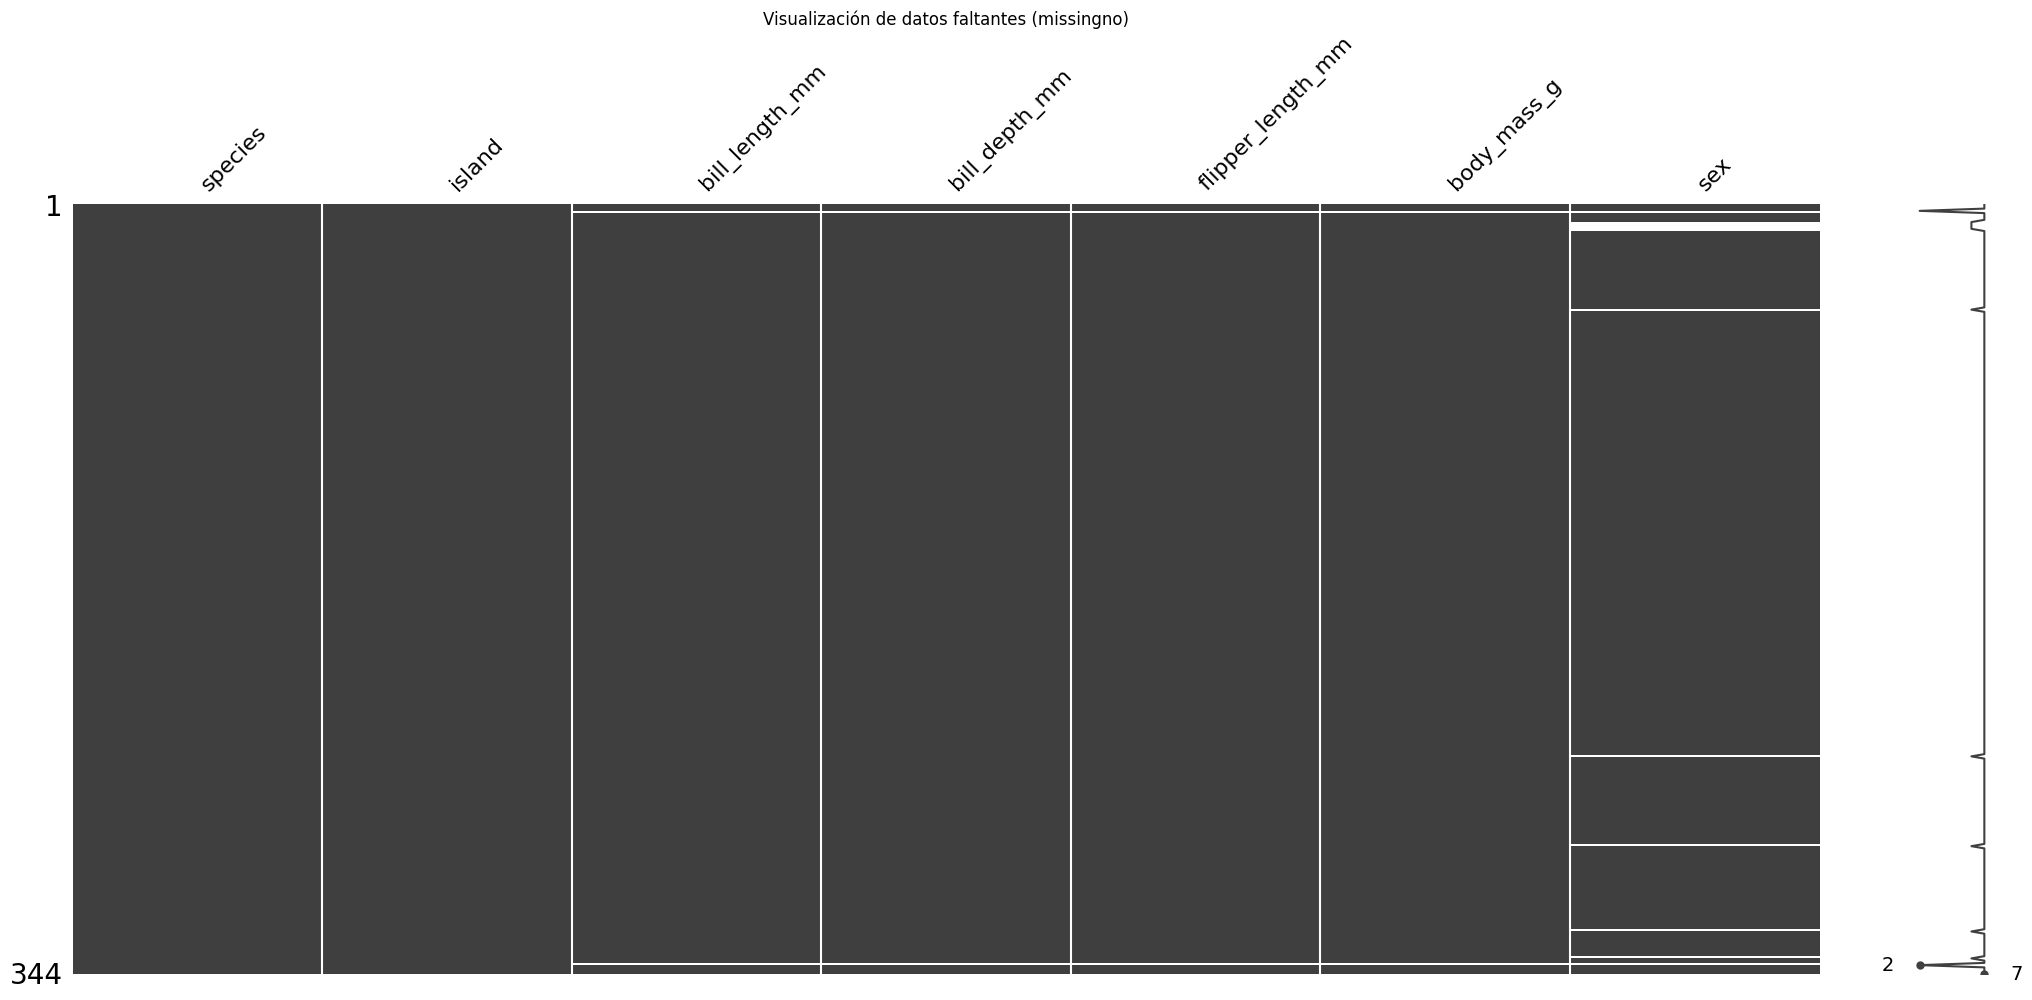

In [9]:
# Análisis de datos faltantes en el conjunto de datos
missing_counts = data.isnull().sum()
print('Cantidad de datos faltantes por columna:')
print(missing_counts)

# Visualización gráfica de los datos faltantes
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Visualización de datos faltantes (heatmap)')
plt.xlabel('Columnas')
plt.ylabel('Registros')
plt.show()

# Si tienes instalado missingno, puedes usarlo para una visualización más específica
try:
    import missingno as msno
    msno.matrix(data)
    plt.title('Visualización de datos faltantes (missingno)')
    plt.show()
except ImportError:
    print('missingno no está instalado. Solo se muestra el heatmap con seaborn.')

## Comentarios sobre el manejo de datos faltantes
- Se observa que hay dos pingüinos con muchos datos faltantes, por lo que deben ser eliminados del conjunto de datos para evitar sesgos o problemas en el análisis.
- También hay algunos pingüinos que tienen valores faltantes en la columna 'sex'. Esto plantea la disyuntiva de eliminar solo la columna 'sex', eliminar únicamente los pingüinos con ese valor faltante, o intentar imputar los valores ausentes.
- En este caso, dado que la cantidad de pingüinos con datos faltantes es baja y el conjunto de datos es suficientemente grande, es seguro eliminar todas las filas que contengan valores nulos.
- Esta decisión ayuda a mantener la calidad del análisis y evita introducir incertidumbre por imputaciones poco confiables.

In [10]:
# Eliminar todas las instancias que contienen datos faltantes
num_original = data.shape[0]
data_limpio = data.dropna()
num_limpio = data_limpio.shape[0]
num_eliminados = num_original - num_limpio
print(f'Tamaño original del conjunto de datos: {num_original}')
print(f'Tamaño del conjunto de datos limpio: {num_limpio}')
print(f'Cantidad de instancias eliminadas: {num_eliminados}')

Tamaño original del conjunto de datos: 344
Tamaño del conjunto de datos limpio: 333
Cantidad de instancias eliminadas: 11


## ¿Qué es el Análisis de Componentes Principales (PCA)?
El Análisis de Componentes Principales (PCA, por sus siglas en inglés) es una técnica estadística utilizada para reducir la dimensionalidad de un conjunto de datos, manteniendo la mayor cantidad posible de información relevante.

PCA transforma las variables originales en un nuevo conjunto de variables llamadas componentes principales, que son combinaciones lineales de las variables originales y están ordenadas según la cantidad de varianza que explican.

Esta técnica es útil para visualizar datos multidimensionales, eliminar redundancias y facilitar el análisis exploratorio y la construcción de modelos predictivos.

## ¿Qué es One Hot Encoding?
One Hot Encoding es una técnica utilizada para transformar variables categóricas en variables numéricas, facilitando su uso en algoritmos de machine learning que requieren datos numéricos.

Consiste en crear una nueva columna para cada categoría posible de la variable original, asignando un valor de 1 si la instancia pertenece a esa categoría y 0 en caso contrario.

Por ejemplo, si la columna 'island' tiene los valores 'Biscoe', 'Dream' y 'Torgersen', One Hot Encoding generará tres columnas: 'island_Biscoe', 'island_Dream' y 'island_Torgersen'. Cada fila tendrá un 1 en la columna correspondiente a su isla y 0 en las demás.

Esta técnica evita que los modelos interpreten las categorías como valores ordinales y permite trabajar correctamente con variables categóricas en análisis estadísticos y modelos predictivos.

In [12]:
# Transformar variables categóricas en numéricas para PCA, excluyendo la columna target 'species'
from sklearn.preprocessing import OneHotEncoder
target_col = 'species'
categorical_cols = [col for col in data_limpio.select_dtypes(include=['object', 'category']).columns if col != target_col]
encoder = OneHotEncoder(sparse=False, drop='first')
encoded = encoder.fit_transform(data_limpio[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))
# Concatenar variables numéricas y las codificadas, manteniendo la columna target
numerical_df = data_limpio.drop(columns=categorical_cols).reset_index(drop=True)
data_pca_ready = pd.concat([numerical_df, encoded_df], axis=1)
print('Conjunto de datos listo para PCA (sin transformar la columna target):')
print(data_pca_ready.head())

Conjunto de datos listo para PCA (sin transformar la columna target):
  species  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0  Adelie            39.1           18.7              181.0       3750.0   
1  Adelie            39.5           17.4              186.0       3800.0   
2  Adelie            40.3           18.0              195.0       3250.0   
3  Adelie            36.7           19.3              193.0       3450.0   
4  Adelie            39.3           20.6              190.0       3650.0   

   island_Dream  island_Torgersen  sex_Male  
0           0.0               1.0       1.0  
1           0.0               1.0       0.0  
2           0.0               1.0       0.0  
3           0.0               1.0       0.0  
4           0.0               1.0       1.0  


/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/preprocessing/_encoders.py:828: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


   Componente  Varianza Acumulada
0           1            0.999892
1           2            0.999971
2           3            0.999996
3           4            0.999999
4           5            1.000000
5           6            1.000000
6           7            1.000000


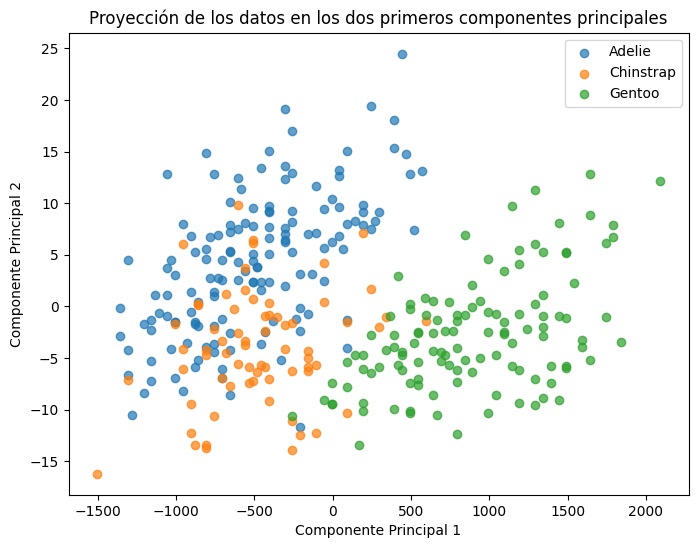

In [13]:
# Calcular los componentes principales excluyendo la columna target
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

X = data_pca_ready.drop(columns=['species'])
y = data_pca_ready['species']

# PCA
pca = PCA()
X_pca = pca.fit_transform(X)

# Tabla de varianza explicada acumulada
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
import pandas as pd
tabla_varianza = pd.DataFrame({'Componente': np.arange(1, len(varianza_acumulada)+1), 'Varianza Acumulada': varianza_acumulada})
print(tabla_varianza)

# Gráfico de proyecciones en los dos primeros componentes
plt.figure(figsize=(8,6))
for especie in y.unique():
    idx = y == especie
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=especie, alpha=0.7)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Proyección de los datos en los dos primeros componentes principales')
plt.legend()
plt.show()